In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.15"

from grater_jax.disk_model.objective_functions import objective_model, objective_fit, log_likelihood, Parameter_Index
from grater_jax.disk_model.SLD_utils import DoubleHenyeyGreenstein_SPF, InterpolatedUnivariateSpline_SPF, EMP_PSF, DustEllipticalDistribution2PowerLaws, Winnie_PSF
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_debug_nans", True) <-- can use this to trace issues at the cost of runtime

In [2]:
# Generates a simple psf function image
scale_factor = 1
image = fits.open("GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

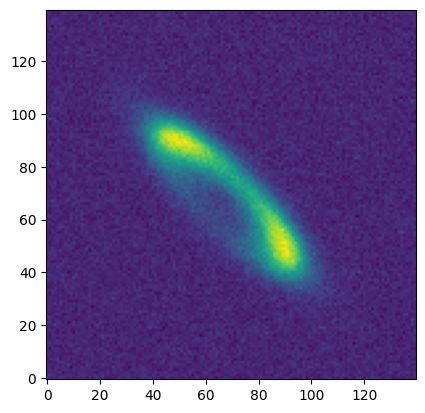

In [3]:
name = "inject_disk_inc75_spf2_betaneg.fits"
target_img = jnp.array(fits.getdata("inject_disk_inc75_spf2_betaneg.fits"))
plt.imshow(target_img,origin='lower')
err_map = jnp.ones(target_img.shape)*10

EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
start_spf_params = InterpolatedUnivariateSpline_SPF.params
start_psf_params = EMP_PSF.params

# Initializing spline spf parameters
start_spf_params['num_knots'] = 5
start_spf_params['knot_values'] = jnp.ones(5)*0.1
start_spf_params['backscatt_bound'] = -0.9
start_spf_params['frontscatt_bound'] = 0.9

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
start_disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
start_disk_params['sma'] = 28
start_disk_params['inclination'] = 80
start_disk_params['position_angle'] = 48
start_disk_params['beta'] = 0.5


In [4]:
from grater_jax.optimization.optimize_framework import Optimizer, OptimizeUtils
from grater_jax.disk_model.objective_functions import objective_model, objective_ll, objective_fit, Parameter_Index
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import *

opt = Optimizer(ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF,
                start_disk_params, start_spf_params, start_psf_params, Parameter_Index.misc_params)

In [5]:
opt.inc_bound_knots() # call this method only if you have a good predifined inclination, otherwise don't use it
opt.set_empirical_psf(emp_psf_image) # <-- Only necessary if you have an empirical_psf_image
opt.initialize_knots(target_img) # <-- This needs to be called first before any modeling or jit compiling if spline spf is being used

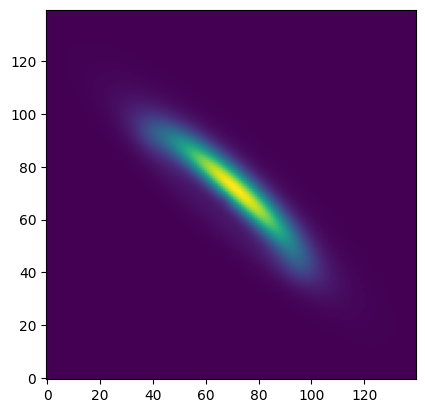

In [6]:
plt.imshow(opt.get_model(),origin='lower')

In [9]:
fit_keys = ['alpha_in', 'alpha_out', 'sma', 'inclination', 'position_angle', 'x_center', 'y_center', 'knot_values', 'e','beta']
logscaled_params = ['knot_values']
array_params = ['knot_values']
bounds = ([0.1, -15, 0, 0, 0, 60, 60, np.zeros(opt.spf_params["num_knots"]), 0,-5],
          [20, -0.1, 150, 180, 400, 80, 80, 1e4*np.ones(opt.spf_params["num_knots"]), 1,5])

opt.scipy_bounded_optimize(fit_keys, bounds, logscaled_params, array_params, target_img, err_map, use_grad = True, disp_soln = True, iters = 2000)
optimal_image = opt.get_model()

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 2.821929737980968
        x: [ 5.647e+00 -5.839e+00 ...  0.000e+00 -1.911e+00]
      nit: 52
      jac: [ 9.011e-03 -4.654e-03 ...  1.425e-01 -7.322e-03]
     nfev: 135
     njev: 135
 hess_inv: <14x14 LbfgsInvHessProduct with dtype=float64>


Disk Params: {'accuracy': 0.005, 'alpha_in': np.float64(5.64675617405113), 'alpha_out': np.float64(-5.8390922348767615), 'sma': np.float64(26.219144648798554), 'e': np.float64(0.0), 'ksi0': 3.0, 'gamma': 2.0, 'beta': np.float64(-1.91103882874071), 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': np.float64(76.52207714336163), 'position_angle': np.float64(45.16810479259484), 'x_center': np.float64(69.76047665956322), 'y_center': np.float64(69.98409926816015), 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.98480775, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.98480775, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([1.3893061 , 1.91999192, 1.        , 0.62572057, 0.1197401 ],      dtype=float64), 'frontscatt_bound': 0.9}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 50.0, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': Array(17059.562402

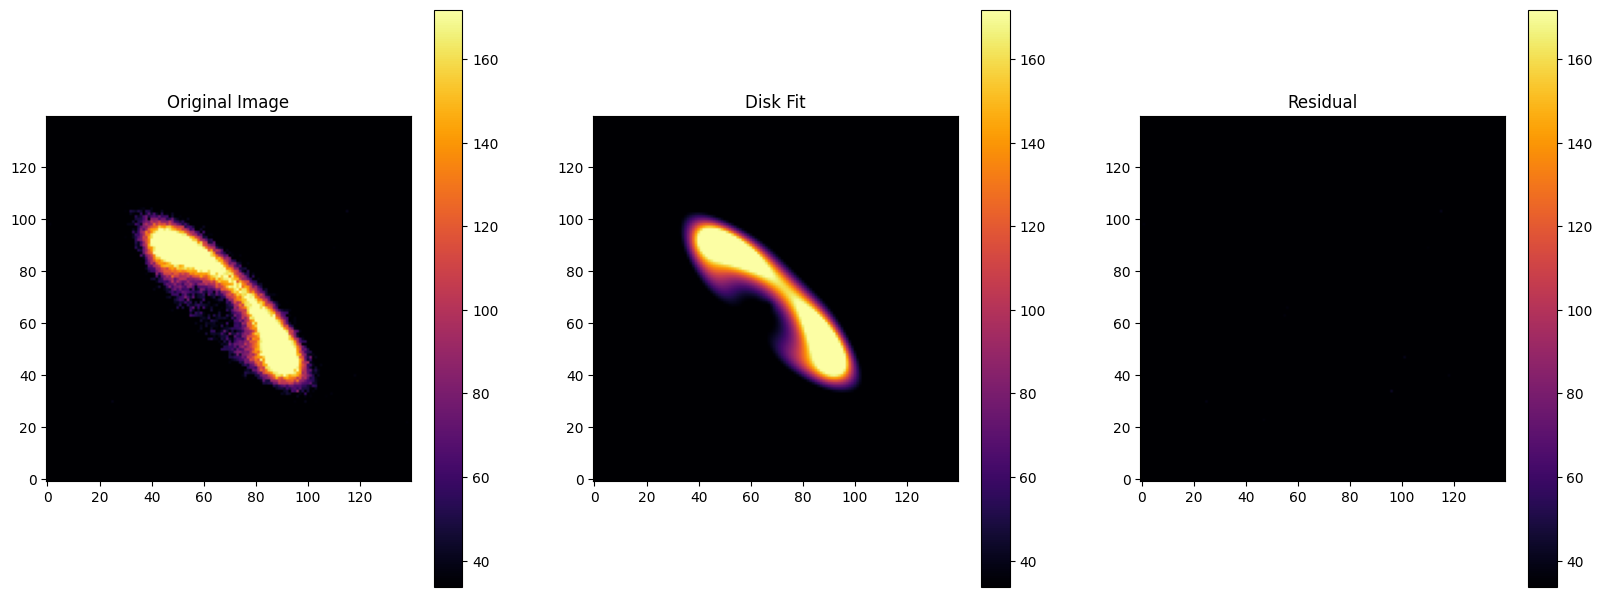

In [10]:
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()
target_image = target_img
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 95)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

plt.tight_layout
plt.savefig('{}_scipyminimize_img.png'.format(name))

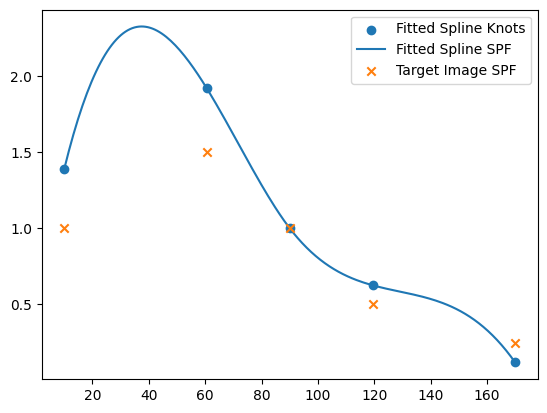

In [14]:
knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(knot_locs))
plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.scatter(knot_locs,[1.0,1.5,1.0,0.5,0.25],marker='x',zorder=10)

plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])
plt.savefig('{}_scipyminimize_spf.png'.format(name))

In [ ]:
# For MCMC, spline values are log scaled, the optimizer class passes them in as log(spf_params) and they are exponated in the lambda expression, this evens out the markov chains
# helping MCMC work better

mc_model = opt.mcmc(fit_keys, logscaled_params, array_params, target_image, err_map, bounds, nwalkers=100, niter=2000, burns=0, continue_from=True)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 9/2000 [00:03<12:58,  2.56it/s]

Disk Params: {'accuracy': 0.005, 'alpha_in': np.float64(5.6467612313316575), 'alpha_out': np.float64(-5.839091120275941), 'sma': np.float64(26.21914544256575), 'e': np.float64(6.671694550532784e-05), 'ksi0': 3.0, 'gamma': 2.0, 'beta': np.float64(-1.9110434460536454), 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': np.float64(76.52207219080476), 'position_angle': np.float64(45.168108330751), 'x_center': np.float64(69.76047982611918), 'y_center': np.float64(69.98410153560627), 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.98480775, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.98480775, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([1.38930388, 1.91999595, 1.        , 0.62572094, 0.11974005],      dtype=float64), 'frontscatt_bound': 0.9}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 50.0, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': 

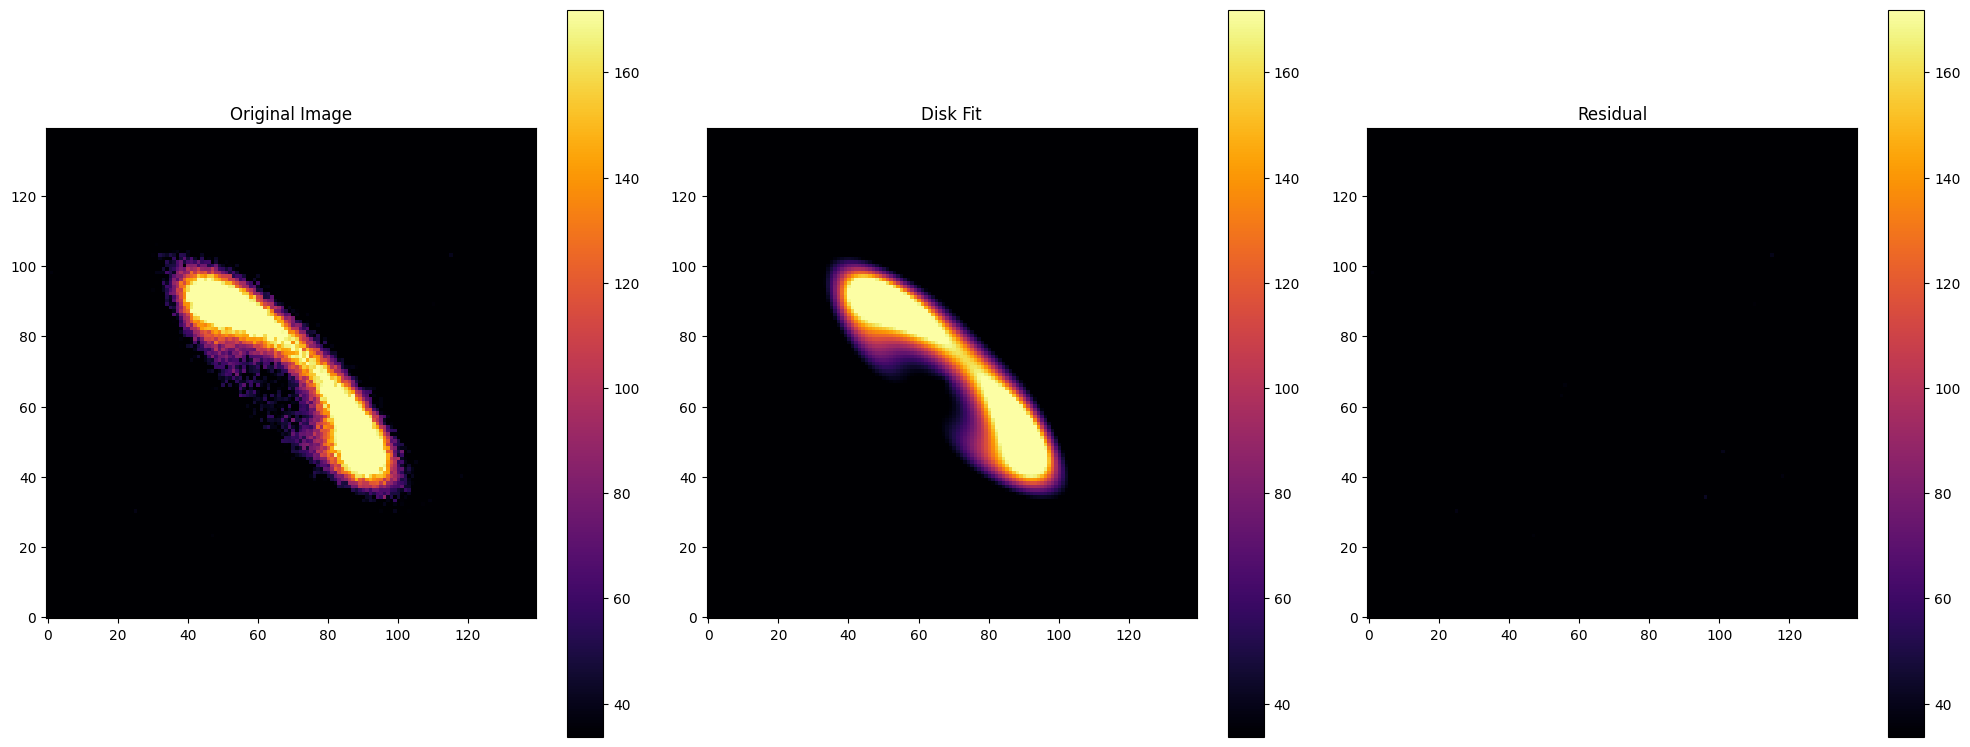

In [16]:
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()
target_image = target_img
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 95)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

plt.tight_layout()
plt.savefig('{}_mcmc_img.png'.format(name))

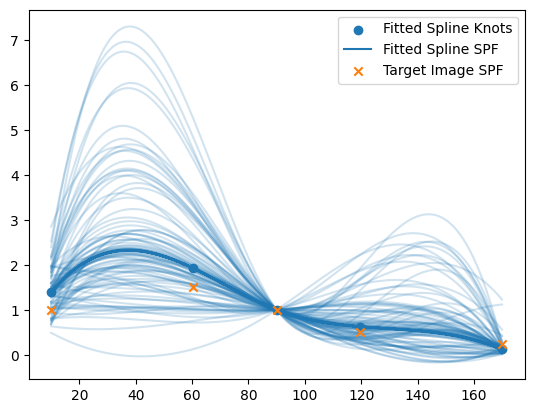

In [20]:
knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(knot_locs))
plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.scatter(knot_locs,[1.0,1.5,1.0,0.5,0.25],marker='x',zorder=10)
for i in np.random.random(200)*len(mc_model.scaled_chain):
    j = int(np.random.random()*100)
    i = int(i)
    kvals = mc_model.scaled_chain[i,j,7:12]
    plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(kvals,knots=knot_locs)(x_vals)/InterpolatedUnivariateSpline_SPF.pack_pars(kvals,knots=knot_locs)(90),color='tab:blue',alpha=0.2)
plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])

plt.savefig('{}_mcmc_spf.png'.format(name))